# Jaguar Re-ID — ViT Improved v9

**Architecture** : ViT + `relu`, `embed_dim=64`, **6 blocs** (vs 3), `AdamW(wd=1e-4)`, `Dropout(0.1)`, `LabelSmoothing(0.1)`, pas d'augmentation.  
**Hypothese** : v6 (3 blocs, 0.435 Kaggle) plafonne a 81 % val. Plus de blocs transformer → couches d'attention plus profondes → features hierarchiques plus riches → meilleure discrimination individuelle.

### Diagnostic v8 (point de depart)

| Experience | Resultat | Lecon |
|-----------|----------|-------|
| v7 (+ Aug, Dropout garde) | Kaggle 0.258 (-41 % vs v6) | Sur-regularisation : 4 techniques cassent le sweep |
| v8 (+ Aug, - Dropout) | Kaggle 0.354 (-19 % vs v6) | Aug != Dropout : invariance spatiale nuit au Re-ID |
| **Conclusion** | **Meilleure config = v6** | Abandonner l'augmentation, explorer la profondeur |

## 1. Setup & data loading

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks
from sklearn.preprocessing import normalize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from src.config import *
from src.data import load_data, load_test_pairs, make_dataset

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SUBMISSION_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

I0000 00:00:1776610962.024472  280949 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776610962.055075  280949 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776610962.827019  280949 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1776610963.709422  280949 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [2]:
MODEL_NAME   = 'vit_improved_v9'
AUGMENTATION = 'none'    # retour a v6 : pas d'augmentation

# ViT architecture hyperparameters
EMBED_DIM  = 64      # identique v6
NUM_BLOCKS = 6       # v6 avait 3 blocs → on double la profondeur
PATCH_SIZE = 16      # identique v6
ACTIVATION = 'relu'  # identique v3+

# Regularisation — identique v6 (la meilleure config)
WEIGHT_DECAY    = 1e-4   # AdamW decoupled weight decay
DROPOUT_RATE    = 0.1    # retabli (v6 level) — retire en v8, on le remet
LABEL_SMOOTHING = 0.1    # "noisy targets" du cours (v6 : +72 % Kaggle)

# Retrain fix (herite de v3, bug fixe en v8)
RETRAIN_EPOCHS_MULTIPLIER = 4
RETRAIN_EPOCHS_MIN        = 60

In [3]:
X_train, y_train = load_data('train')
X_val, y_val     = load_data('val')
X_test, test_filenames = load_data('test')
test_pairs_df = load_test_pairs()

# One-hot encoding pour CategoricalCrossentropy + label smoothing
y_train_oh = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_oh   = tf.keras.utils.to_categorical(y_val,   NUM_CLASSES)

train_ds = make_dataset(X_train, y_train_oh, training=True, augmentation=AUGMENTATION)
val_ds   = make_dataset(X_val,   y_val_oh)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Labels: int {y_train.shape} -> one-hot {y_train_oh.shape}")
print(f"Train batches: {len(train_ds)} | Val batches: {len(val_ds)}")

W0000 00:00:1776610966.414150  280949 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1776610966.547155  280949 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13209 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


Train: (1516, 224, 224, 3) | Val: (379, 224, 224, 3) | Test: (371, 224, 224, 3)
Labels: int (1516,) -> one-hot (1516, 31)
Train batches: 48 | Val batches: 12


## 2. Model architecture

Architecture v9 : **6 blocs transformer** au lieu de 3. Tout le reste est identique a v6.

| Composant | v6 (meilleur) | v7 | v8 | **v9** |
|-----------|---------------|----|----|--------|
| NUM_BLOCKS | 3 | 3 | 3 | **6** |
| Dropout | 0.1 | 0.1 | 0.0 | **0.1** |
| Augmentation | none | light | light | **none** |
| Label smoothing | 0.1 | 0.1 | 0.1 | **0.1** |
| Kaggle pub | **0.435** | 0.258 | 0.354 | **?** |

In [4]:
def positional_embedding(embedded_patches):
    """One-hot positional encoding (cours) : concat one-hot(position) to each patch."""
    embedded_patches_shape = tf.shape(embedded_patches)
    batchsize = embedded_patches_shape[0]
    sequence_length = embedded_patches_shape[1]
    indices = tf.range(sequence_length)
    one_hot_indices = tf.one_hot(indices, sequence_length)
    expanded_one_hot_indices = tf.expand_dims(one_hot_indices, axis=0)
    repeated_expanded_one_hot_indices = tf.repeat(expanded_one_hot_indices, [batchsize], axis=0)
    positional_embedded_patches = tf.concat([repeated_expanded_one_hot_indices, embedded_patches], axis=-1)
    return positional_embedded_patches


def build_model():
    input_tensor = keras.Input((IMG_SIZE, IMG_SIZE, 3))
    x = input_tensor

    # Patch embedding
    x = layers.Conv2D(EMBED_DIM, (PATCH_SIZE, PATCH_SIZE), strides=(PATCH_SIZE, PATCH_SIZE),
                      activation='linear', use_bias=False, padding='valid')(x)
    sequence_length = x.shape[1] * x.shape[2]  # 14*14 = 196
    sqrt_sequence_length = np.sqrt(sequence_length)

    x = layers.Reshape((sequence_length, EMBED_DIM))(x)

    # Positional encoding : one-hot concat
    x = layers.Lambda(positional_embedding)(x)
    real_embedding_dim = sequence_length + EMBED_DIM  # 196 + 64 = 260

    # Transformer blocks (NUM_BLOCKS = 6 en v9, vs 3 en v6)
    for _ in range(NUM_BLOCKS):
        # Self-attention
        old_x = x
        x = layers.LayerNormalization()(x)

        Q = layers.Dense(real_embedding_dim, activation=ACTIVATION)(x)
        K = layers.Dense(real_embedding_dim, activation=ACTIVATION)(x)
        V = layers.Dense(real_embedding_dim, activation=ACTIVATION)(x)

        Kt = layers.Lambda(lambda t: tf.transpose(t, [0, 2, 1]))(K)
        QKt = layers.Lambda(lambda ts: tf.matmul(ts[0], ts[1]) / sqrt_sequence_length)([Q, Kt])
        Masks = layers.Softmax()(QKt)
        x = layers.Lambda(lambda ts: tf.matmul(ts[0], ts[1]))([Masks, V])
        x = layers.Add()([x, old_x])

        # Feed-forward
        old_x = x
        x = layers.LayerNormalization()(x)
        x = layers.Dense(real_embedding_dim, activation=ACTIVATION)(x)
        x = layers.Dense(real_embedding_dim, activation=ACTIVATION)(x)
        x = layers.Add()([x, old_x])

    # Classification head (identique v6)
    x = layers.Flatten()(x)
    x = layers.Dense(real_embedding_dim, activation=ACTIVATION, name='embedding')(x)
    x = layers.Dropout(DROPOUT_RATE)(x)  # retabli (v6 level)
    output_tensor = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(input_tensor, output_tensor, name=MODEL_NAME)
    return model


model = build_model()
model.summary()

Model: "vit_improved_v9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 14, 14,    │     49,152 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 196, 64)   │          0 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 196, 260)  │          0 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 196, 260)  │        520 │ lambda[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 260, 196)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 196, 196)  │          0 │ dense[0][0],      │
│                     │                   │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Softmax)   │ (None, 196, 196)  │          0 │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 196, 260)  │          0 │ softmax[0][0],    │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 196, 260)  │          0 │ lambda_3[0][0],   │
│                     │                   │            │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 260)  │        520 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 196, 260)  │     67,860 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 196, 260)  │          0 │ dense_4[0][0],    │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 260)  │        520 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 15,349,143 (58.55 MB)

 Trainable params: 15,349,143 (58.55 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Hyperparameter sweep

Meme sweep que v6/v8. **Objectif** : verifier que les LRs hauts (5e-4, 1e-3) fonctionnent avec 6 blocs.  
En v6, BEST_LR = 5e-4. On s'attend a un comportement similaire (meme regularisation).

In [5]:
def train_and_eval(lr, run_name):
    m = build_model()
    m.compile(
        optimizer=optimizers.AdamW(learning_rate=lr, weight_decay=WEIGHT_DECAY),
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
        metrics=['accuracy']
    )
    log_dir = os.path.join(LOG_DIR, MODEL_NAME, run_name)
    hist = m.fit(
        train_ds,
        validation_data=val_ds,
        epochs=100,
        callbacks=[
            callbacks.EarlyStopping(
                monitor='val_loss', patience=10, restore_best_weights=True
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0
            ),
            callbacks.TensorBoard(log_dir=log_dir),
        ],
        verbose=0
    )
    _, val_acc = m.evaluate(val_ds, verbose=0)
    best_epoch = np.argmin(hist.history['val_loss']) + 1
    print(f"  {run_name}: val_acc={val_acc:.4f} (best epoch={best_epoch})")
    return {'val_acc': val_acc, 'best_epoch': best_epoch, 'hist': hist.history}

In [6]:
lr_candidates = [1e-2, 1e-3, 5e-4, 1e-4]

results = {}
print(f"=== LR sweep ({MODEL_NAME}, blocks={NUM_BLOCKS}, wd={WEIGHT_DECAY}, dropout={DROPOUT_RATE}, ls={LABEL_SMOOTHING}) ===")
for lr in lr_candidates:
    run_name = f'lr_{lr}'
    results[run_name] = train_and_eval(lr, run_name)

=== LR sweep (vit_improved_v9, blocks=6, wd=0.0001, dropout=0.1, ls=0.1) ===


I0000 00:00:1776610973.123195  281080 service.cc:153] XLA service 0x7f94e806f130 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776610973.123232  281080 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1776610973.239885  281080 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776610974.150025  281080 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1776610974.281271  281080 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_19898__.195
I0000 00:00:1776610974.833108  281222 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_180', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776610975.034407  281220 subprocess_compilation.cc:348] ptxas

  lr_0.01: val_acc=0.0950 (best epoch=21)


I0000 00:00:1776611034.257949  281081 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_67007__.195
I0000 00:00:1776611039.365035  281079 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_67007__.195
I0000 00:00:1776611041.709449  281079 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_68926__.48
I0000 00:00:1776611043.010631  281079 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_68926__.48


  lr_0.001: val_acc=0.1029 (best epoch=1)


I0000 00:00:1776611056.325789  281078 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_96014__.195
I0000 00:00:1776611061.483571  281079 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_96014__.195
I0000 00:00:1776611065.152119  281079 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_97933__.48
I0000 00:00:1776611066.483309  281080 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_97933__.48


  lr_0.0005: val_acc=0.7889 (best epoch=100)


I0000 00:00:1776611138.460597  281079 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_201024__.195
I0000 00:00:1776611143.604022  281077 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_201024__.195
I0000 00:00:1776611147.274307  281077 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_202943__.48
I0000 00:00:1776611148.606925  281079 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_202943__.48


  lr_0.0001: val_acc=0.0950 (best epoch=100)


In [7]:
rows = [{'Config': name, 'Val Accuracy': r['val_acc'], 'Best Epoch': r['best_epoch']}
        for name, r in results.items()]
results_df = pd.DataFrame(rows).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)
display(results_df)

BEST_CONFIG = results_df.iloc[0]['Config']
BEST_LR = float(BEST_CONFIG.split('_')[1])
BEST_EPOCH = int(results_df.iloc[0]['Best Epoch'])
print(f"\nBest: {BEST_CONFIG} \u2192 val_acc={results_df.iloc[0]['Val Accuracy']:.4f}")
print(f"BEST_LR = {BEST_LR}, BEST_EPOCH = {BEST_EPOCH}")
print(f"(v6 reference : BEST_LR=5e-4, BEST_EPOCH=95, val_acc=81.27 %)")

,Config,Val Accuracy,Best Epoch
0,lr_0.0005,0.788918,100
1,lr_0.001,0.102902,1
2,lr_0.01,0.094987,21
3,lr_0.0001,0.094987,100



Best: lr_0.0005 → val_acc=0.7889
BEST_LR = 0.0005, BEST_EPOCH = 100
(v6 reference : BEST_LR=5e-4, BEST_EPOCH=95, val_acc=81.27 %)


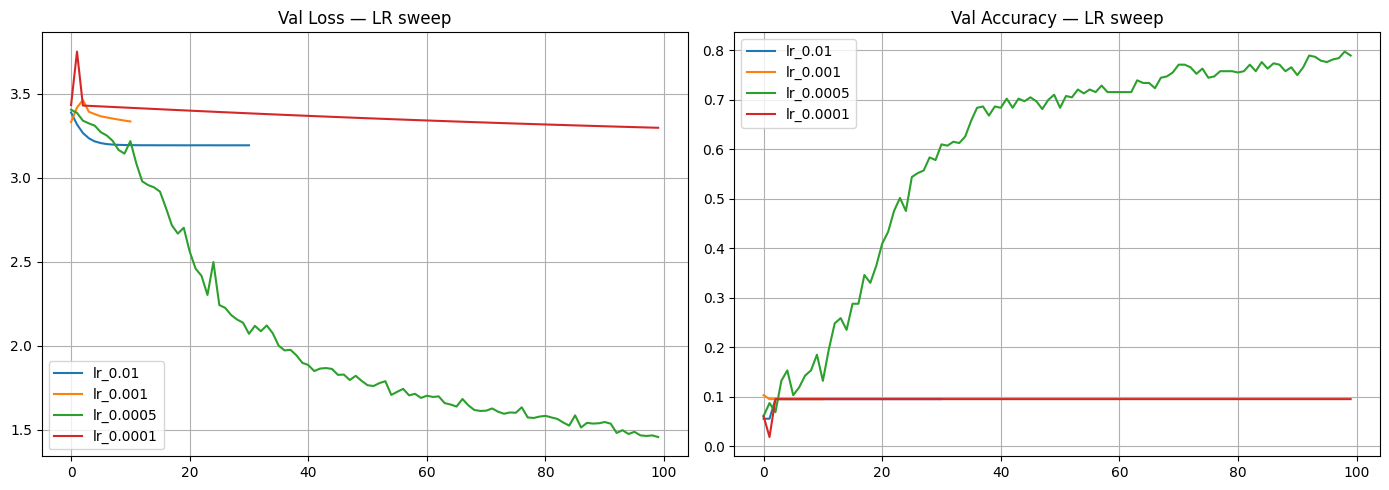

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, r in results.items():
    axes[0].plot(r['hist']['val_loss'],     label=name)
    axes[1].plot(r['hist']['val_accuracy'], label=name)
axes[0].set_title('Val Loss \u2014 LR sweep'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Val Accuracy \u2014 LR sweep'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_lr_sweep.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Evaluation (best config)

In [9]:
model = build_model()
model.compile(
    optimizer=optimizers.AdamW(learning_rate=BEST_LR, weight_decay=WEIGHT_DECAY),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=['accuracy']
)
log_dir = os.path.join(LOG_DIR, MODEL_NAME, f'best_{datetime.now().strftime("%Y%m%d-%H%M%S")}')

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
        callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1),
    ],
    verbose=1
)

Epoch 1/100


I0000 00:00:1776611222.141886  281077 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_312973__.195


46/48 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0508 - loss: 58.1099

I0000 00:00:1776611227.321401  281077 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_312973__.195


48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.0513 - loss: 56.8183

I0000 00:00:1776611230.154047  281077 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_314892__.48
I0000 00:00:1776611231.512544  281080 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_314892__.48


48/48 ━━━━━━━━━━━━━━━━━━━━ 17s 165ms/step - accuracy: 0.0620 - loss: 27.0169 - val_accuracy: 0.0950 - val_loss: 3.4107 - learning_rate: 5.0000e-04
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.0785 - loss: 3.4379 - val_accuracy: 0.0923 - val_loss: 3.4266 - learning_rate: 5.0000e-04
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.0904 - loss: 3.4218 - val_accuracy: 0.0950 - val_loss: 3.4180 - learning_rate: 5.0000e-04
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.0943 - loss: 3.4144 - val_accuracy: 0.0950 - val_loss: 3.4069 - learning_rate: 5.0000e-04
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.0838 - loss: 3.3998 - val_accuracy: 0.0950 - val_loss: 3.3998 - learning_rate: 5.0000e-04
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.0765 - loss: 3.3686 - val_accuracy: 0.0950 - val_loss: 3.3439 - learning_rate: 5.0000e-04
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.1009 - 

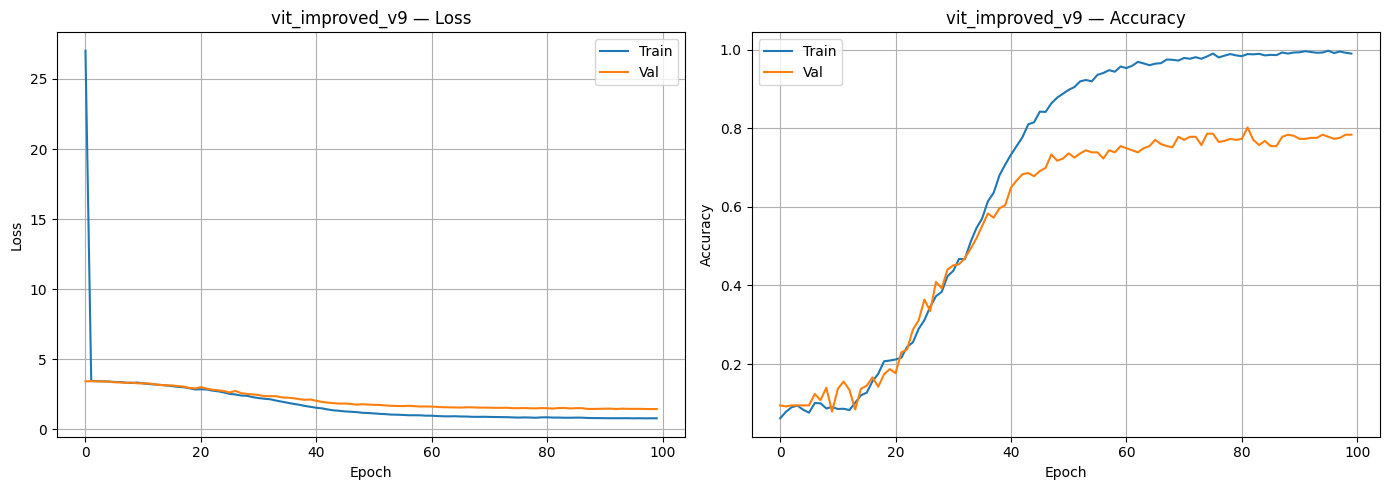

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title(f'{MODEL_NAME} \u2014 Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title(f'{MODEL_NAME} \u2014 Accuracy'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_history.png'), dpi=150, bbox_inches='tight')
plt.show()

In [11]:
train_loss, train_acc = model.evaluate(train_ds, verbose=0)
val_loss, val_acc     = model.evaluate(val_ds, verbose=0)

print(f"{MODEL_NAME} (blocks={NUM_BLOCKS}, LR={BEST_LR}, wd={WEIGHT_DECAY}, dropout={DROPOUT_RATE}, ls={LABEL_SMOOTHING}):")
print(f"  Train \u2014 Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
print(f"  Val   \u2014 Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
print(f"  Gap train/val: {(train_acc - val_acc)*100:.1f} pts  (v6: 18.7, v8: 19.0)")

I0000 00:00:1776611356.098181  281079 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_314892__.48
I0000 00:00:1776611356.378440  307524 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_174', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776611356.761204  307525 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_174', 80 bytes spill stores, 80 bytes spill loads



vit_improved_v9 (blocks=6, LR=0.0005, wd=0.0001, dropout=0.1, ls=0.1):
  Train — Loss: 0.6976, Acc: 1.0000
  Val   — Loss: 1.4328, Acc: 0.7836
  Gap train/val: 21.6 pts  (v6: 18.7, v8: 19.0)


I0000 00:00:1776611358.410838  281079 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1611574__.39
I0000 00:00:1776611359.884896  281079 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1612419__.39


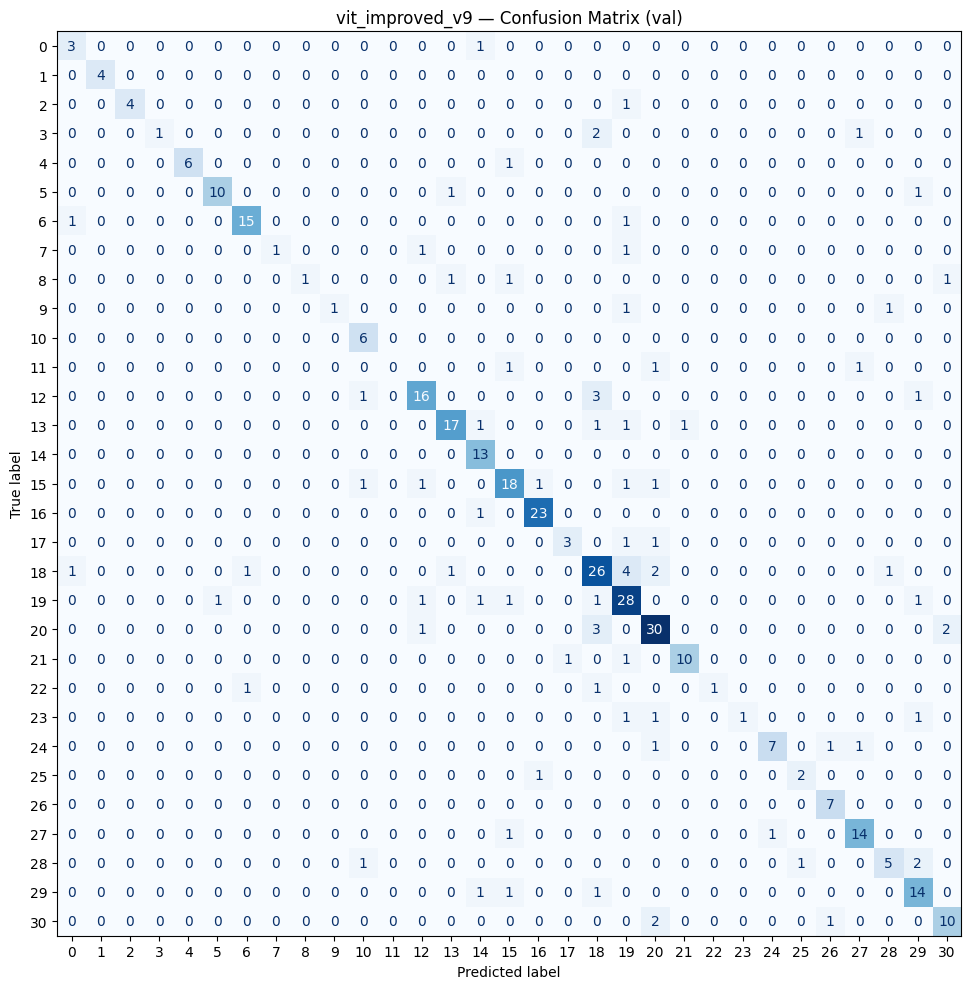

In [12]:
y_val_pred = model.predict(val_ds, verbose=0).argmax(axis=1)

cm = confusion_matrix(y_val, y_val_pred)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'{MODEL_NAME} \u2014 Confusion Matrix (val)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Kaggle submission

In [13]:
X_all = np.concatenate([X_train, X_val])
y_all = np.concatenate([y_train, y_val])
y_all_oh = tf.keras.utils.to_categorical(y_all, NUM_CLASSES)
all_ds = make_dataset(X_all, y_all_oh, training=True, augmentation=AUGMENTATION, batch_size=BATCH_SIZE)

RETRAIN_EPOCHS = max(BEST_EPOCH * RETRAIN_EPOCHS_MULTIPLIER, RETRAIN_EPOCHS_MIN)
print(f"BEST_EPOCH du sweep : {BEST_EPOCH}")
print(f"RETRAIN_EPOCHS      : {RETRAIN_EPOCHS}  (= max({BEST_EPOCH}*{RETRAIN_EPOCHS_MULTIPLIER}, {RETRAIN_EPOCHS_MIN}))")
print(f"Retraining on full dataset ({len(X_all)} images) for {RETRAIN_EPOCHS} epochs")

final_model = build_model()
final_model.compile(
    optimizer=optimizers.AdamW(learning_rate=BEST_LR, weight_decay=WEIGHT_DECAY),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=['accuracy']
)

final_log = os.path.join(LOG_DIR, MODEL_NAME, f'final_{datetime.now().strftime("%Y%m%d-%H%M%S")}')
final_history = final_model.fit(
    all_ds, epochs=RETRAIN_EPOCHS,
    callbacks=[
        # Fix herite de v8 : ReduceLROnPlateau sur loss pour eviter l'explosion du gradient
        callbacks.ReduceLROnPlateau(
            monitor='loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1
        ),
        callbacks.TensorBoard(log_dir=final_log),
    ],
    verbose=1
)
final_train_acc = final_model.evaluate(all_ds, verbose=0)[1]
print(f"\nFinal retrain train acc: {final_train_acc:.4f}")

BEST_EPOCH du sweep : 100
RETRAIN_EPOCHS      : 400  (= max(100*4, 60))
Retraining on full dataset (1895 images) for 400 epochs
Epoch 1/400


I0000 00:00:1776611369.340983  281077 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1631582__.195


59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0436 - loss: 50.7288

I0000 00:00:1776611374.747117  281078 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1631582__.195
I0000 00:00:1776611375.254233  307799 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3', 20 bytes spill stores, 20 bytes spill loads

I0000 00:00:1776611375.361714  307790 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776611375.515662  307786 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_158', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776611375.611316  307787 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_158', 40 bytes spill stores, 40 bytes spill loads

I0000 00:00:1776611375.657772  307791 subprocess_compilat

60/60 ━━━━━━━━━━━━━━━━━━━━ 23s 230ms/step - accuracy: 0.0533 - loss: 23.2609 - learning_rate: 5.0000e-04
Epoch 2/400


I0000 00:00:1776611386.342495  281078 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_add_multiply_reduce_fusion', 96 bytes spill stores, 92 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_add_multiply_reduce_fusion_2', 88 bytes spill stores, 88 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_add_reduce_fusion_16', 40 bytes spill stores, 40 bytes spill loads



60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.0887 - loss: 3.2943 - learning_rate: 5.0000e-04
Epoch 3/400
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1040 - loss: 3.2113 - learning_rate: 5.0000e-04
Epoch 4/400
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1266 - loss: 3.1418 - learning_rate: 5.0000e-04
Epoch 5/400
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1488 - loss: 3.0533 - learning_rate: 5.0000e-04
Epoch 6/400
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2084 - loss: 2.9555 - learning_rate: 5.0000e-04
Epoch 7/400
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2433 - loss: 2.8171 - learning_rate: 5.0000e-04
Epoch 8/400
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2982 - loss: 2.7120 - learning_rate: 5.0000e-04
Epoch 9/400
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3889 - loss: 2.5107 - learning_rate: 5.0000e-04
Epoch 10/400
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4396 - loss: 2.3194 - learning_ra

I0000 00:00:1776611685.226651  281080 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1941824__.48
I0000 00:00:1776611686.839812  281078 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1941824__.48
I0000 00:00:1776611686.990963  322937 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_174', 16 bytes spill stores, 16 bytes spill loads

I0000 00:00:1776611687.345169  322943 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_174', 84 bytes spill stores, 84 bytes spill loads




Final retrain train acc: 1.0000


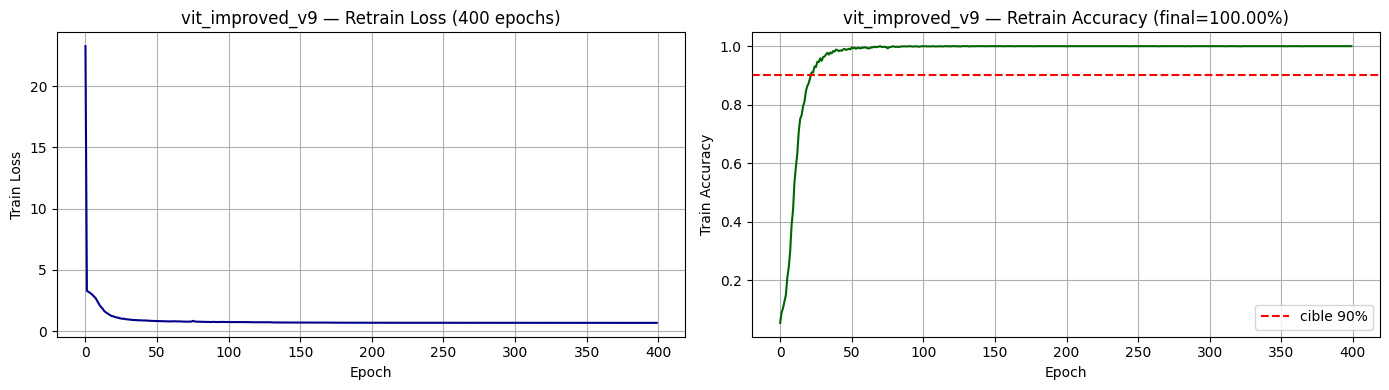

✅ Retrain converge : train acc = 100.00%


In [14]:
# Courbe de convergence du retrain
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(final_history.history['loss'], color='darkblue')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Train Loss')
axes[0].set_title(f'{MODEL_NAME} \u2014 Retrain Loss ({RETRAIN_EPOCHS} epochs)'); axes[0].grid(True)

axes[1].plot(final_history.history['accuracy'], color='darkgreen')
axes[1].axhline(0.90, color='red', linestyle='--', label='cible 90%')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Train Accuracy')
axes[1].set_title(f'{MODEL_NAME} \u2014 Retrain Accuracy (final={final_train_acc:.2%})')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_retrain.png'), dpi=150, bbox_inches='tight')
plt.show()

if final_train_acc < 0.90:
    print(f"\u26a0\ufe0f  Retrain train acc = {final_train_acc:.2%} < 90%. Verifier la courbe (divergence ou convergence lente ?)")
else:
    print(f"\u2705 Retrain converge : train acc = {final_train_acc:.2%}")

In [15]:
# Extract embeddings from the named embedding layer
embedding_model = keras.Model(
    inputs=final_model.input,
    outputs=final_model.get_layer('embedding').output,
    name=f'{MODEL_NAME}_embedding'
)

test_embeddings = embedding_model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
test_embeddings_norm = normalize(test_embeddings, axis=1)
print(f"Embedding shape: {test_embeddings_norm.shape}")

fname_to_idx = {fname: i for i, fname in enumerate(test_filenames)}
query_idx   = test_pairs_df['query_image'].map(fname_to_idx).values
gallery_idx = test_pairs_df['gallery_image'].map(fname_to_idx).values

CHUNK = 1000
similarities = np.empty(len(query_idx), dtype=np.float32)
for start in range(0, len(query_idx), CHUNK):
    sl = slice(start, start + CHUNK)
    q = test_embeddings_norm[query_idx[sl]]
    g = test_embeddings_norm[gallery_idx[sl]]
    similarities[sl] = np.clip((q * g).sum(axis=1), 0, 1)

submission = pd.DataFrame({'row_id': test_pairs_df['row_id'], 'similarity': similarities})
submission_path = os.path.join(SUBMISSION_DIR, f'submission_{MODEL_NAME}.csv')
submission.to_csv(submission_path, index=False)
print(f"Saved: {submission_path}")
display(submission.head())

I0000 00:00:1776611689.334789  281077 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1942924__.37


 1/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step

I0000 00:00:1776611690.685256  281078 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1943745__.37
I0000 00:00:1776611690.881538  323067 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3', 20 bytes spill stores, 20 bytes spill loads

I0000 00:00:1776611691.007618  323060 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776611691.271349  323067 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_90', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776611691.396417  323070 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_90', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1776611691.840177  323068 subprocess_compilation.cc:

12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 401ms/step
Embedding shape: (371, 260)
Saved: /home/franck/kaggle_jaguar_classification/submissions/submission_vit_improved_v9.csv


,row_id,similarity
0,0,0.418169
1,1,0.651518
2,2,0.400961
3,3,0.443502
4,4,0.396383


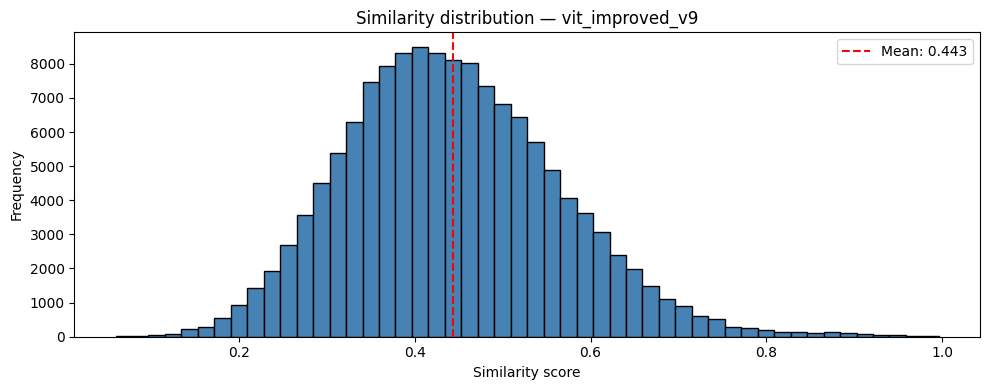

Similarity mean: 0.4429  (v6: 0.4643, v8: 0.6156)
Similarity std : 0.1228
Similarity range: [0.0593, 0.9964]


In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(similarities, bins=50, color='steelblue', edgecolor='black')
ax.axvline(similarities.mean(), color='red', linestyle='--', label=f'Mean: {similarities.mean():.3f}')
ax.set_xlabel('Similarity score'); ax.set_ylabel('Frequency')
ax.set_title(f'Similarity distribution \u2014 {MODEL_NAME}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_similarity.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Similarity mean: {similarities.mean():.4f}  (v6: 0.4643, v8: 0.6156)")
print(f"Similarity std : {similarities.std():.4f}")
print(f"Similarity range: [{similarities.min():.4f}, {similarities.max():.4f}]")

In [17]:
print(f"""
ViT Improved v9 (blocks={NUM_BLOCKS}, AdamW + wd={WEIGHT_DECAY} + Dropout={DROPOUT_RATE} + LabelSmoothing={LABEL_SMOOTHING}):
  Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}
  Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}
  Gap train/val: {(train_acc - val_acc)*100:.1f} pts  (v6: 18.7, v8: 19.0)

  LR: {BEST_LR}, Weight decay: {WEIGHT_DECAY}, Dropout: {DROPOUT_RATE}, LabelSmoothing: {LABEL_SMOOTHING}
  Augmentation: {AUGMENTATION}, Blocks: {NUM_BLOCKS} (v6: 3)
  Best Epoch: {BEST_EPOCH} / Retrain Epochs: {RETRAIN_EPOCHS}
  Retrain train acc: {final_train_acc:.4f}
  Embedding dim: {test_embeddings_norm.shape[1]}
  Similarity mean: {similarities.mean():.4f}  (v6: 0.4643, v8: 0.6156)
  Similarity range: [{similarities.min():.4f}, {similarities.max():.4f}]
""")


ViT Improved v9 (blocks=6, AdamW + wd=0.0001 + Dropout=0.1 + LabelSmoothing=0.1):
  Train - Loss: 0.6976, Acc: 1.0000
  Val   - Loss: 1.4328, Acc: 0.7836
  Gap train/val: 21.6 pts  (v6: 18.7, v8: 19.0)

  LR: 0.0005, Weight decay: 0.0001, Dropout: 0.1, LabelSmoothing: 0.1
  Augmentation: none, Blocks: 6 (v6: 3)
  Best Epoch: 100 / Retrain Epochs: 400
  Retrain train acc: 1.0000
  Embedding dim: 260
  Similarity mean: 0.4429  (v6: 0.4643, v8: 0.6156)
  Similarity range: [0.0593, 0.9964]



## 6. Observations & Verdict

### Results

| Metrique | v6 (3 blocs, meilleur) | v8 (- Dropout + Aug) | **v9 (6 blocs)** |
|----------|------------------------|----------------------|------------------|
| NUM_BLOCKS | 3 | 3 | **6** |
| BEST_LR | 5e-4 | 5e-4 | TODO |
| BEST_EPOCH (sweep) | 95 | 89 | TODO |
| Train accuracy | 100.00 % | 100.00 % | TODO |
| Val accuracy | 81.27 % | 81.00 % | TODO |
| Gap train/val | 18.7 pts | 19.0 pts | TODO |
| Retrain train acc | 100.00 % | 100.00 % | TODO |
| Similarity mean | 0.4643 | 0.6156 | TODO |
| Kaggle public | **0.435** | 0.354 | **TODO** |
| Kaggle private | **0.421** | 0.354 | **TODO** |

### Analysis

- TODO : Val accuracy avec 6 blocs > 81.27 % (v6) ? Si oui → profondeur aide.
- TODO : BEST_LR stable a 5e-4 ? Si 6 blocs ralentissent la convergence → LR different.
- TODO : Gap train/val reduit ? Plus de blocs = plus de capacite = potentiellement plus d'overfitting.
- TODO : Similarity mean proche de 0.46 (v6) ? Indique que les embeddings sont aussi discriminants.
- TODO : Kaggle vs 0.435 (v6). 6 blocs font-ils mieux que 3 ?

### Verdict

- [ ] Improvable -> Instructions for v10
- [ ] Not Improvable -> Ceiling reached, why ?
- [ ] Dead-end -> We ff cette architecture, why ?

### Interpretation

_Free Space : points cles pour la soutenance._

- **Hypothese testee** : plus de blocs transformer = features plus hierarchiques = meilleur Re-ID ?
- Si v9 > v6 (0.435) → **la profondeur aide** sur 1516 images avec les bonnes regularisations.
- Si v9 ≈ v6 → **le plafond est architectural** (single-head attention, one-hot positional, dimension 260).
- Si v9 < v6 → **trop de blocs = overfitting aggrave** → prochaine piste : patch plus petit ou architectures alternatives.